In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Overview

In [3]:
District_Demographics = pd.read_excel('District_Demographics.xlsx')
#District_Demographics.head(5)
District_Txn_Users = pd.read_excel('District_Txn_and_Users.xlsx')
#District_Txn_Users.head(5)
State_DeviceData = pd.read_excel('State_DeviceData.xlsx')
#State_DeviceData.head(5)
State_TxnSplit = pd.read_excel('State_TxnSplit.xlsx')
#State_TxnSplit.head(5)
State_Txn_and_Users = pd.read_excel('State_Txn_and_Users.xlsx')
#State_Txn_and_Users.head(5)

In [16]:
State_Txn_and_Users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             504 non-null    object 
 1   Year              504 non-null    int64  
 2   Quarter           504 non-null    int64  
 3   Transactions      504 non-null    int64  
 4   Amount (INR)      503 non-null    float64
 5   ATV (INR)         504 non-null    float64
 6   Registered Users  504 non-null    int64  
 7   App Opens         504 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 31.6+ KB


In [22]:
District_Txn_Users.isnull().sum()

State                0
Year                 0
Quarter              0
District             0
Code                28
Transactions         0
Amount (INR)         0
ATV (INR)            4
Registered Users     0
App Opens            0
dtype: int64

In [11]:
District_Demographics.shape
District_Txn_Users.shape
State_DeviceData.shape
State_TxnSplit.shape
State_Txn_and_Users.shape

(504, 8)

In [90]:
State_Txn_and_Users.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
499    False
500    False
501    False
502    False
503    False
Length: 504, dtype: bool

In [70]:
missing_count = District_Txn_Users.isna().sum()
missing_perc = (missing_count/len(District_Txn_Users))*100
missing_report = pd.DataFrame({'missing_count': missing_count,
                              'missing_perc': missing_perc})
missing_report

,missing_count,missing_perc
State,0,0.000000
Year,0,0.000000
Quarter,0,0.000000
District,0,0.000000
Code,28,0.273224
Transactions,0,0.000000
Amount (INR),0,0.000000
ATV (INR),4,0.039032
Registered Users,0,0.000000
App Opens,0,0.000000


In [69]:
District_Txn_Users.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens,False
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0,AN01
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0,AN02
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0,AN03
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0,AN01
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0,AN02


# Data Cleaning and Processing

In [71]:
District_Txn_Users.drop(columns=[False], inplace=True)

In [72]:
District_Txn_Users.head()

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0


In [74]:
District_Txn_Users[District_Txn_Users.isna().any(axis = 1)]

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
224,Arunachal Pradesh,2018,1,Anjaw,AR01,0,0.000000e+00,NaN,278,0
241,Arunachal Pradesh,2018,1,Shi Yomi,AR17,0,0.000000e+00,NaN,49,0
266,Arunachal Pradesh,2018,2,Shi Yomi,AR17,0,0.000000e+00,NaN,80,0
291,Arunachal Pradesh,2018,3,Shi Yomi,AR17,0,0.000000e+00,NaN,118,0
3133,Jammu & Kashmir,2018,1,Mirpur,NaN,1320,3.052182e+06,2312.259022,544,0
3134,Jammu & Kashmir,2018,1,Muzaffarabad,NaN,13,1.455980e+04,1119.984877,41,0
3155,Jammu & Kashmir,2018,2,Mirpur,NaN,1885,4.089199e+06,2169.336200,795,0
3156,Jammu & Kashmir,2018,2,Muzaffarabad,NaN,75,3.688235e+05,4917.646448,57,0
3177,Jammu & Kashmir,2018,3,Mirpur,NaN,2789,7.804798e+06,2798.421577,1133,0
3178,Jammu & Kashmir,2018,3,Muzaffarabad,NaN,211,5.818788e+05,2757.719318,89,0


In [75]:
District_Txn_Users['Code'] = District_Txn_Users['Code'].fillna('not Available')

In [81]:
District_Txn_Users[District_Txn_Users.isna().any(axis = 1)]

,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens


In [80]:
District_Txn_Users['ATV (INR)'] = District_Txn_Users['ATV (INR)'].fillna(0)

In [88]:
State_Txn_and_Users.isna().sum()

State               0
Year                0
Quarter             0
Transactions        0
Amount (INR)        1
ATV (INR)           0
Registered Users    0
App Opens           0
dtype: int64

In [92]:
State_Txn_and_Users.head()

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


In [102]:
State_Txn_and_Users[State_Txn_and_Users.isna().any(axis = 1)]

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens


In [101]:
State_Txn_and_Users[State_Txn_and_Users['State'] == 'Andhra Pradesh']

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
14,Andhra Pradesh,2018,1,9039585,1.199628e+10,1327.082647,3336450,0
15,Andhra Pradesh,2018,2,12353918,2.288391e+10,1852.360868,4402540,0
16,Andhra Pradesh,2018,3,25626061,3.571804e+10,1393.817200,5427617,0
17,Andhra Pradesh,2018,4,30759548,5.147378e+10,1673.424441,6857409,0
18,Andhra Pradesh,2019,1,57264522,8.376060e+10,1462.696151,8283019,0
19,Andhra Pradesh,2019,2,56409015,1.136345e+11,2014.474437,9389003,81375251
20,Andhra Pradesh,2019,3,76288614,1.394479e+11,1827.899826,10458693,310953542
21,Andhra Pradesh,2019,4,107218103,2.009483e+11,1874.201370,11757883,411201518
22,Andhra Pradesh,2020,1,127677357,2.527372e+11,1979.499108,13022060,486513773
23,Andhra Pradesh,2020,2,144917855,3.025837e+11,2087.966936,14319675,494341698


In [98]:
amt_prev = State_Txn_and_Users.loc[
(State_Txn_and_Users['Year'] == 2020) &
(State_Txn_and_Users['Quarter'] == 4),
'Amount (INR)'].iloc[0]

amt_next = State_Txn_and_Users.loc[
(State_Txn_and_Users['Year'] == 2021) &
(State_Txn_and_Users['Quarter'] == 2),
'Amount (INR)'].iloc[0]

amt2021q1 = (amt_prev + amt_next)/2

State_Txn_and_Users.loc[
(State_Txn_and_Users['Year'] == 2021) &
(State_Txn_and_Users['Quarter'] == 1),
'Amount (INR)'] = amt2021q1

In [100]:
atv = State_Txn_and_Users.loc[
(State_Txn_and_Users['Year'] == 2021) &
(State_Txn_and_Users['Quarter'] == 1),
'Amount (INR)'].iloc[0]

atvt = State_Txn_and_Users.loc[
(State_Txn_and_Users['Year'] == 2021) &
(State_Txn_and_Users['Quarter'] == 1),
'Transactions'].iloc[0]

atv_inr = atv/atvt

State_Txn_and_Users.loc[
(State_Txn_and_Users['Year'] == 2021) &
(State_Txn_and_Users['Quarter'] == 1),
'ATV (INR)'] = atv_inr

# Summary

In [99]:
total_states = len(District_Demographics['State'].unique())

print('Total no. of States : ', total_states)

Total no. of States :  36


In [128]:
District_Demographics.head()

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
1,Andhra Pradesh,Chittoor,Chittoor,4170468,15152.0,275,AP02,Chittoor
2,Andhra Pradesh,East Godavari,Kakinada,5151549,10807.0,477,AP03,East Godavari
3,Andhra Pradesh,Guntur,Guntur,4889230,11391.0,429,AP04,Guntur
4,Andhra Pradesh,YSR,Kadapa,2884524,15359.0,188,AP13,YSR


In [133]:
District_count = District_Demographics.groupby('State')['District'].count().reset_index(name='Total Districts')
District_count

,State,Total Districts
0,Andaman & Nicobar Islands,3
1,Andhra Pradesh,13
2,Arunachal Pradesh,25
3,Assam,34
4,Bihar,38
5,Chandigarh,1
6,Chhattisgarh,28
7,Dadra & Nagar Haveli and Daman & Diu,3
8,Delhi,11
9,Goa,2


In [138]:
District_Demographics[District_Demographics['State']== 'Andaman & Nicobar Islands']

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
697,Andaman & Nicobar Islands,Nicobar,Car Nicobar,36842,1841.0,20,AN01,Nicobars
698,Andaman & Nicobar Islands,North and Middle Andaman,Mayabunder,105597,3736.0,28,AN02,North and Middle Andaman
699,Andaman & Nicobar Islands,South Andaman,Port Blair,238142,2672.0,89,AN03,South Andaman


In [146]:
district_count = (District_Demographics.groupby('State')['District'].nunique())
highest_district_state = district_count.idxmax()
max_district = district_count.max()
print(highest_district_state, max_district)

Uttar Pradesh 75


# Exploratory Data analysis

In [133]:
District_Demographics.head(5)
#District_Txn_Users.head(5)
#State_DeviceData.head(5)
#State_TxnSplit.head(5)
#State_Txn_and_Users.head(5)

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
1,Andhra Pradesh,Chittoor,Chittoor,4170468,15152.0,275,AP02,Chittoor
2,Andhra Pradesh,East Godavari,Kakinada,5151549,10807.0,477,AP03,East Godavari
3,Andhra Pradesh,Guntur,Guntur,4889230,11391.0,429,AP04,Guntur
4,Andhra Pradesh,YSR,Kadapa,2884524,15359.0,188,AP13,YSR


# 1 Analyze transaction trend over the year for each state

In [162]:
#1. Calculate the total number of transactions and total transaction amount for each state over the years. Display the results in a tabular format.

state_and_year_wise_total = State_Txn_and_Users.groupby(['State', 'Year']).agg({
    'Transactions' : 'sum',
'Amount (INR)' : 'sum'})

state_and_year_wise_total.head(5)

Transactions  Amount (INR)
State                     Year                            
Andaman & Nicobar Islands 2018         58021  1.890761e+08
                          2019        133104  4.734648e+08
                          2020        446274  1.296423e+09
                          2021        586166  1.662362e+09
Andhra Pradesh            2018      77779112  1.220720e+11

In [184]:
#2. Identify the top 5 states with the highest transaction volumes and the top 5 states with the lowest transaction volumes. Display the results.

#the top 5 states with the highest transaction volumes
top_5_state = (
    State_Txn_and_Users
    .groupby('State')['Transactions']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .reset_index()
)
top_5_state

,State,Transactions
0,Karnataka,2981044533
1,Maharashtra,2833670154
2,Telangana,2347430243
3,Andhra Pradesh,1781091169
4,Rajasthan,1382918930


In [185]:
# the top 5 states with the lowest transaction volumes

top_5_state = (
    State_Txn_and_Users
    .groupby('State')['Transactions']
    .sum()
    .sort_values(ascending=True)
    .head(5)
    .reset_index()
)
top_5_state

,State,Transactions
0,Lakshadweep,71610
1,Andaman & Nicobar Islands,1223565
2,Ladakh,1880109
3,Mizoram,2162776
4,Meghalaya,5648913


# 2.2: Identify the most common transaction types in each state and quarter

In [201]:
most_used_trans_type = ( State_TxnSplit.groupby(['State', 'Quarter','Transaction Type']).size()
    .reset_index(name='Frequency'))
frequent = most_used_trans_type.loc[
    most_used_trans_type.groupby(['State', 'Quarter'])['Frequency'].idxmax().sort_values(ascending=True)
]
frequent



,State,Quarter,Transaction Type,Frequency
0,Andaman & Nicobar Islands,1,Financial Services,4
5,Andaman & Nicobar Islands,2,Financial Services,4
10,Andaman & Nicobar Islands,3,Financial Services,3
15,Andaman & Nicobar Islands,4,Financial Services,3
20,Andhra Pradesh,1,Financial Services,4
...,...,...,...,...
695,Uttarakhand,4,Financial Services,3
700,West Bengal,1,Financial Services,4
705,West Bengal,2,Financial Services,4
710,West Bengal,3,Financial Services,3


# 2.3: Determine the device brand with the highest number of registered users in each state. Display the results in a tabular format.

In [206]:
State_DeviceData.head(5)
registered_users_count = (State_DeviceData.groupby(['State', 'Brand'])['Registered Users'].sum().sort_values(ascending = False).reset_index())
registered_users_count

,State,Brand,Registered Users
0,Maharashtra,Xiaomi,80281858
1,Maharashtra,Samsung,69415065
2,Uttar Pradesh,Xiaomi,64303360
3,Maharashtra,Vivo,52988543
4,Karnataka,Xiaomi,52595345
...,...,...,...
443,Lakshadweep,Motorola,405
444,Sikkim,Asus,308
445,Ladakh,Micromax,305
446,Lakshadweep,Gionee,43


# 2.4: Create a list of the top district per state based on population

In [11]:
#1. For each state, identify the district with the highest population. Display the results in a tabular format.

highest_pop_district = District_Demographics.loc[District_Demographics.groupby('State')['Population'].idxmax()].reset_index()
highest_pop_district

,index,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,699,Andaman & Nicobar Islands,South Andaman,Port Blair,238142,2672.00,89,AN03,South Andaman
1,2,Andhra Pradesh,East Godavari,Kakinada,5151549,10807.00,477,AP03,East Godavari
2,28,Arunachal Pradesh,Papum Pare,Yupia,176385,2875.00,61,AR16,Papum Pare
3,64,Assam,Nagaon,Nagaon,2826006,3831.00,738,AS27,Nagaon
4,97,Bihar,Patna,Patna,5772804,3202.00,1803,BR26,Patna
5,700,Chandigarh,Chandigarh,Chandigarh,1055450,114.00,9258,CH01,Chandigarh
6,133,Chhattisgarh,Raipur,Raipur,2160876,2892.00,750,CG24,Raipur
7,703,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,Silvassa,343709,491.00,700,DD01,Dadra and Nagar Haveli
8,732,Delhi,North West Delhi,Kanjhawala,3656539,130.00,8254,DL06,North West
9,138,Goa,North Goa,Panaji,817761,1736.00,471,GA01,North Goa


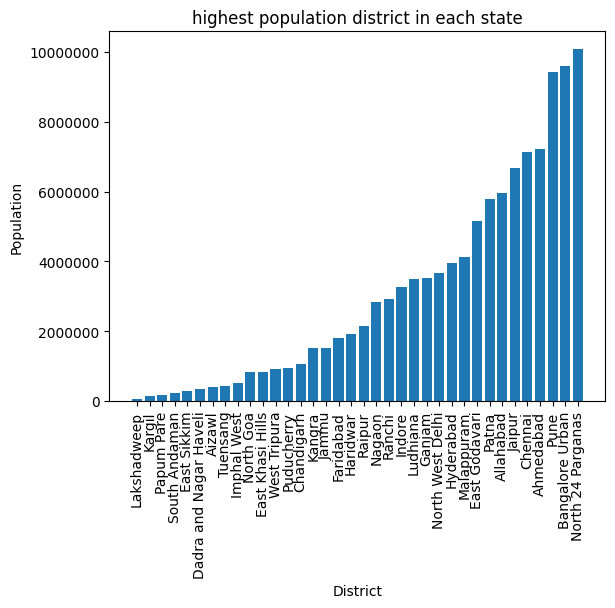

In [20]:
#2. Create a column chart depicting the district with the highest population for each state.

highest_pop_district = District_Demographics.loc[District_Demographics.groupby('State')['Population'].idxmax()].reset_index()
highest_pop_district = highest_pop_district.sort_values(by = 'Population')
plt.figure()
plt.bar(highest_pop_district['District'],
         highest_pop_district['Population'])

plt.xticks(rotation = 90)
plt.xlabel('District')
plt.ylabel('Population')
plt.title('highest population district in each state')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# 2.5: Calculate the average transaction value (ATV) for each state

In [51]:
#1. Compute the average transaction value for each state. Display the results in a tabular format.

atv = State_Txn_and_Users.loc[State_Txn_and_Users.groupby('State')['ATV (INR)'].idxmax()]
atv.sort_values('ATV (INR)')

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
103,Dadra & Nagar Haveli and Daman & Diu,2019,2,489656,8.244413e+08,1683.715254,158580,860686
283,Maharashtra,2018,4,46090223,7.951894e+10,1725.288616,13381602,0
89,Chhattisgarh,2019,2,9389945,1.700236e+10,1810.698113,2191066,13206373
234,Kerala,2020,3,21758680,4.016415e+10,1845.890957,5582300,64309022
113,Delhi,2018,2,9373723,1.744630e+10,1861.192175,2756141,0
472,Uttarakhand,2020,3,11818935,2.210351e+10,1870.177894,2365438,40377348
361,Odisha,2020,4,92324950,1.783027e+11,1931.251119,8598751,270085293
209,Jharkhand,2021,2,54002145,1.044326e+11,1933.861022,5701503,184234107
275,Madhya Pradesh,2020,2,76340573,1.479220e+11,1937.659222,11374423,253770044
152,Gujarat,2021,1,94774565,1.837008e+11,1938.291995,14670126,264732874


In [35]:
# 2. Identify the top 5 states with the highest ATV and the top 5 states with the lowest ATV. Display the results.
atv.sort_values(by = 'ATV (INR)', ascending=False).head(5)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
189,Jammu & Kashmir,2019,4,489928,1.929696e+09,3938.733850,673367,998572
8,Andaman & Nicobar Islands,2020,1,41298,1.614763e+08,3910.027418,28368,193586
241,Ladakh,2018,4,35211,1.355228e+08,3848.877978,23883,0
256,Lakshadweep,2019,1,2481,8.786130e+06,3541.366578,1416,0
325,Mizoram,2018,4,55242,1.904269e+08,3447.138998,19365,0


In [36]:
atv.sort_values(by = 'ATV (INR)', ascending=True).head(5)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
103,Dadra & Nagar Haveli and Daman & Diu,2019,2,489656,8.244413e+08,1683.715254,158580,860686
283,Maharashtra,2018,4,46090223,7.951894e+10,1725.288616,13381602,0
89,Chhattisgarh,2019,2,9389945,1.700236e+10,1810.698113,2191066,13206373
234,Kerala,2020,3,21758680,4.016415e+10,1845.890957,5582300,64309022
113,Delhi,2018,2,9373723,1.744630e+10,1861.192175,2756141,0


# 2.6: Analyze app usage trends

In [49]:
# 1. Calculate the total number of app opens over the years and quarters for each state. Display the results in a tabular format.

app_open_count = (State_Txn_and_Users
                  .groupby(['State', 'Year', 'Quarter'])['App Opens']
                  .sum().reset_index())
app_open_count.sort_values(by = 'App Opens', ascending = False)

,State,Year,Quarter,App Opens
293,Maharashtra,2021,2,1208083592
292,Maharashtra,2021,1,1101976484
222,Karnataka,2021,1,1084917385
405,Rajasthan,2021,2,1072091232
223,Karnataka,2021,2,1051089714
...,...,...,...,...
4,Andaman & Nicobar Islands,2019,1,0
3,Andaman & Nicobar Islands,2018,4,0
2,Andaman & Nicobar Islands,2018,3,0
1,Andaman & Nicobar Islands,2018,2,0


C:\Users\tjtar\AppData\Local\Temp\ipykernel_7616\3489856323.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  state_data['Time'] = state_data['Year'].astype(str) + " Q" + state_data['Quarter'].astype(str)


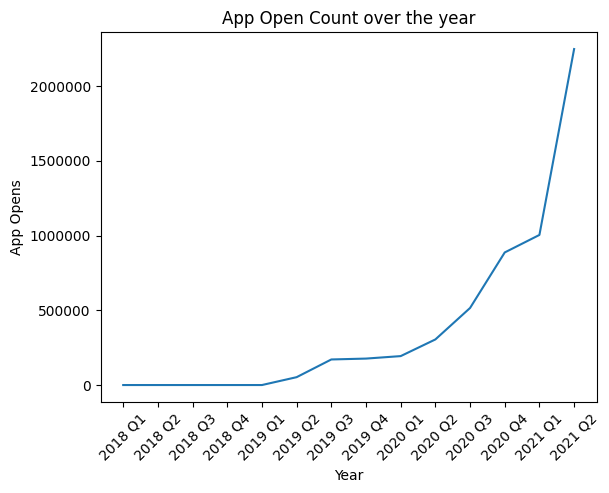

In [59]:
# 2. Identify trends in app usage by creating a line plot showing the number of app opens over time for a selected state.

app_open_count = (State_Txn_and_Users
                  .groupby(['State', 'Year', 'Quarter'])['App Opens']
                  .sum().reset_index())
selected_state = 'Andaman & Nicobar Islands'

state_data = app_open_count[app_open_count['State']== selected_state]

state_data['Time'] = state_data['Year'].astype(str) + " Q" + state_data['Quarter'].astype(str)

plt.figure()
plt.plot(state_data['Time'],
         state_data['App Opens']
)
plt.xticks(rotation = 45)
plt.xlabel('Year')
plt.ylabel('App Opens')
plt.title('App Open Count over the year')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# 2.7: Distribution of transaction types

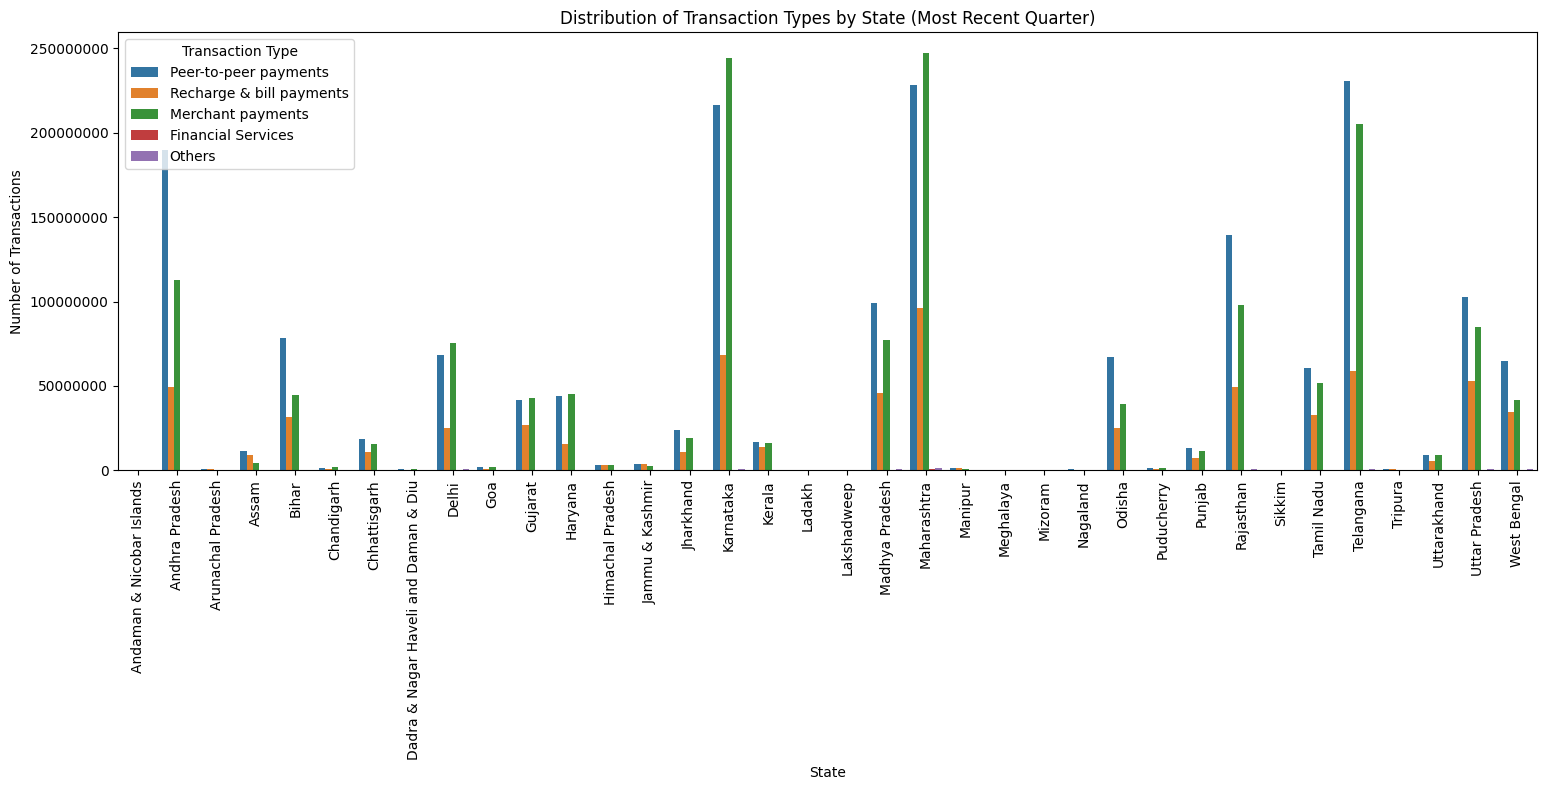

In [77]:
# 1. Create a bar chart showing the distribution of different transaction types for each state for the most recent quarter in the dataset.

latest_year = State_TxnSplit['Year'].max()
latest_quarter = State_TxnSplit[State_TxnSplit['Year'] == latest_year]['Quarter'].max()

recent_data = State_TxnSplit[
(State_TxnSplit['Year'] == latest_year) &
(State_TxnSplit['Quarter'] == latest_quarter)
]


plt.figure(figsize=(15, 8))
sns.barplot(
    data=recent_data,
    x='State',
    y='Transactions',
    hue='Transaction Type'
)
plt.xticks(rotation=90)
plt.title('Distribution of Transaction Types by State (Most Recent Quarter)')
plt.ylabel('Number of Transactions')
plt.xlabel('State')
plt.legend(title='Transaction Type')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# 2.8: Find unique mapping between district name and district code

In [89]:
#1. Identify the unique mapping between district names and district codes from the dataset. [hint: you can use drop_duplicates()]
#2. Create a CSV file containing the unique district name and district code mappings.

unique_mapping = District_Txn_Users[['District','Code']].drop_duplicates()

In [88]:
unique_mapping.to_csv('district_name_code_mapping.csv',index = False)

In [87]:
df = pd.read_csv('district_name_code_mapping.csv')
df.head(5)

,District,Code
0,Nicobars,AN01
1,North And Middle Andaman,AN02
2,South Andaman,AN03
3,Anantapur,AP01
4,Chittoor,AP02


# Task 3: Data Quality Checks
3.1: Ensure data consistency across state and district levels

In [94]:
#1. For each state, calculate the total number of transactions, total transaction amount, and total registered users by summing up the values from the
# district level data.

state_data = District_Txn_Users.groupby(['State', 'Year', 'Quarter']).agg({
    'Transactions' : 'sum',
    'Amount (INR)' : 'sum',
    'Registered Users' : 'sum'
})
state_data

Transactions  Amount (INR)  \
State                     Year Quarter                               
Andaman & Nicobar Islands 2018 1                6658  1.463176e+07   
                               2               11340  2.833854e+07   
                               3               16265  5.555747e+07   
                               4               23758  9.054834e+07   
                          2019 1               30486  1.022997e+08   
...                                              ...           ...   
West Bengal               2020 2            57676797  1.000994e+11   
                               3            79954504  1.568134e+11   
                               4           100340645  1.991655e+11   
                          2021 1           118254052  2.429372e+11   
                               2           141897437  2.794348e+11   

                                        Registered Users  
State                     Year Quarter                    
Andaman & Nicobar Islands 2018 1                    6740  
                               2                    9405  
                               3                   12149  
                               4                   15222  
                          2019 1                   18596  
...                                                  ...  
West Bengal               2020 2                13222022  
                               3                14448366  
                               4                15662093  
                          2021 1                16808799  
                               2                17979979  

[504 rows x 3 columns]

In [96]:
District_Txn_Users.head()
# 2. Compare the results with the corresponding values at the state level to ensure they match.

merged = pd.merge(State_Txn_and_Users,
                 District_Txn_Users,
                 on = ['State', 'Year', 'Quarter'],
                 suffixes = ('State','District'))
merged

,State,Year,Quarter,TransactionsState,Amount (INR)State,ATV (INR)State,Registered UsersState,App OpensState,District,Code,TransactionsDistrict,Amount (INR)District,ATV (INR)District,Registered UsersDistrict,App OpensDistrict
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,Nicobars,AN01,528,1.139849e+06,2158.804548,262,0
1,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,North And Middle Andaman,AN02,442,9.316631e+05,2107.835016,632,0
2,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,South Andaman,AN03,5688,1.256025e+07,2208.201361,5846,0
3,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0,Nicobars,AN01,1120,3.072437e+06,2743.247239,351,0
4,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0,North And Middle Andaman,AN02,825,1.317863e+06,1597.409798,911,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10243,West Bengal,2021,2,141897437,2.794348e+11,1969.273138,17979979,275341466,Purba Bardhaman,WB19,3920729,7.572502e+09,1931.401639,787970,12128849
10244,West Bengal,2021,2,141897437,2.794348e+11,1969.273138,17979979,275341466,Purba Medinipur,WB20,6418522,1.515507e+10,2361.146027,946277,15491958
10245,West Bengal,2021,2,141897437,2.794348e+11,1969.273138,17979979,275341466,Purulia,WB21,1895981,2.790996e+09,1472.059252,435131,8843358
10246,West Bengal,2021,2,141897437,2.794348e+11,1969.273138,17979979,275341466,South Twenty Four Parganas,WB22,6661813,1.339853e+10,2011.243709,1286588,19344293


In [100]:
# 3. Display any discrepancies found between the district-level and state-level data.

discrepancies = merged[
(merged['TransactionsState'] != merged['TransactionsDistrict']) |
(merged['Amount (INR)State'] != merged['Amount (INR)District']) |
(merged['Registered UsersState'] != merged['Registered UsersDistrict'])
]
print(discrepancies[['State', 'Year', 'Quarter',
                     'TransactionsState', 'TransactionsDistrict',
                     'Amount (INR)State', 'Amount (INR)District',
                     'Registered UsersState', 'Registered UsersDistrict']])

                           State  Year  Quarter  TransactionsState  \
0      Andaman & Nicobar Islands  2018        1               6658   
1      Andaman & Nicobar Islands  2018        1               6658   
2      Andaman & Nicobar Islands  2018        1               6658   
3      Andaman & Nicobar Islands  2018        2              11340   
4      Andaman & Nicobar Islands  2018        2              11340   
...                          ...   ...      ...                ...   
10243                West Bengal  2021        2          141897437   
10244                West Bengal  2021        2          141897437   
10245                West Bengal  2021        2          141897437   
10246                West Bengal  2021        2          141897437   
10247                West Bengal  2021        2          141897437   

       TransactionsDistrict  Amount (INR)State  Amount (INR)District  \
0                       528       1.463176e+07          1.139849e+06   
1              

# Task 4: Data Merging and Advanced Analysis
4.1: Ratio of users to population by state

In [106]:
District_Demographics.head(5)

,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,19130.0,213,AP01,Anantapur
1,Andhra Pradesh,Chittoor,Chittoor,4170468,15152.0,275,AP02,Chittoor
2,Andhra Pradesh,East Godavari,Kakinada,5151549,10807.0,477,AP03,East Godavari
3,Andhra Pradesh,Guntur,Guntur,4889230,11391.0,429,AP04,Guntur
4,Andhra Pradesh,YSR,Kadapa,2884524,15359.0,188,AP13,YSR


In [113]:
#1. Merge the State_Txn and Users dataset with the District Demographics dataset to calculate the ratio of registered users to the population for each state. 
#Display the results in a tabular format.
state_pop = District_Demographics.groupby('State')['Population'].sum().reset_index()

latest = State_Txn_and_Users.groupby('State').apply(lambda x: x.sort_values(['Year', 'Quarter'],ascending = False).iloc[0])
latest = latest.reset_index(drop=True)[['State', 'Registered Users']]

merged = pd.merge(latest, state_pop, on='State')
merged['User_Pop_Ratio'] = merged['Registered Users'] / merged['Population']

merged[['State', 'Registered Users', 'Population', 'User_Pop_Ratio']]

C:\Users\tjtar\AppData\Local\Temp\ipykernel_7616\1001243658.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  latest = State_Txn_and_Users.groupby('State').apply(lambda x: x.sort_values(['Year', 'Quarter'],ascending = False).iloc[0])


,State,Registered Users,Population,User_Pop_Ratio
0,Andaman & Nicobar Islands,62095,380581,0.163158
1,Andhra Pradesh,19620905,49378776,0.397355
2,Arunachal Pradesh,270572,1606047,0.168471
3,Assam,3617056,34461385,0.104960
4,Bihar,14972134,103817951,0.144215
5,Chandigarh,448572,1055450,0.425005
6,Chhattisgarh,4837055,25867958,0.186990
7,Dadra & Nagar Haveli and Daman & Diu,344994,586956,0.587768
8,Delhi,11182699,16787941,0.666115
9,Goa,609106,1457723,0.417848


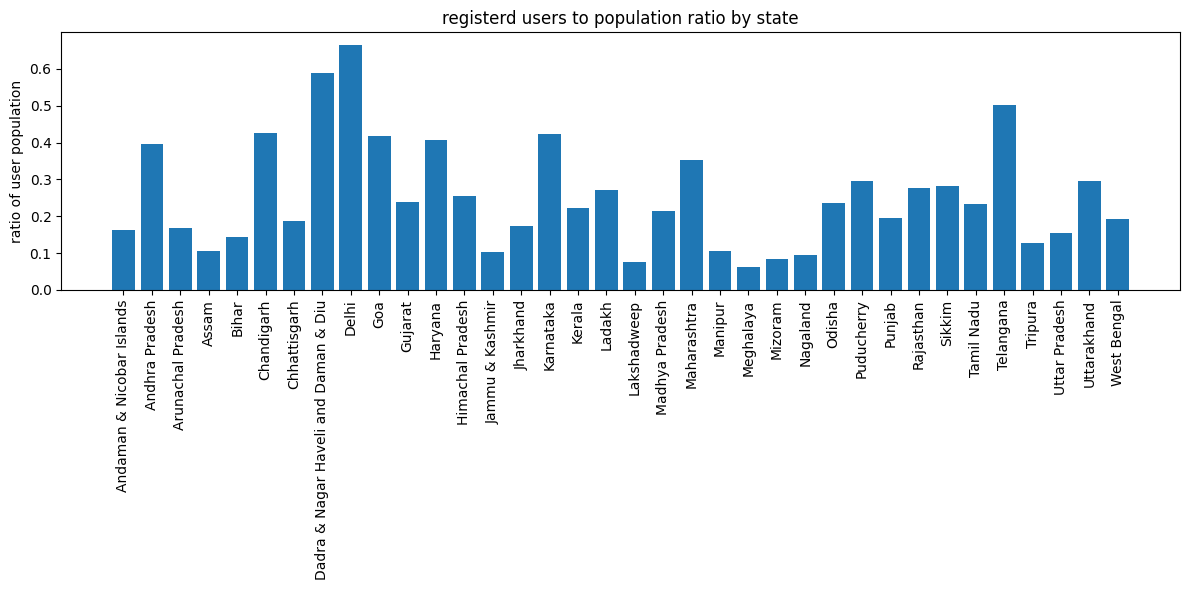

In [117]:
#2. Create a column chart depicting the ratio of users to population by state.

plt.figure(figsize = (12, 6))
plt.bar(merged['State'], merged['User_Pop_Ratio'])
plt.xticks(rotation = 90)
plt.ylabel('ratio of user population')
plt.title('registerd users to population ratio by state')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# 4.2: Correlate population density with transaction volume

In [134]:
#1. Merge the District_Txn and Users dataset with the District Demographics dataset.
merged = pd.merge(State_Txn_and_Users, District_Demographics, on=['State'])

In [128]:
#2. Calculate the correlation between population density and transaction volume.

corr = merged['Density'].corr(merged['Transactions'])
print(f"Correlation between population density and transaction volume: {corr:.2f}")


Correlation between population density and transaction volume: 0.04


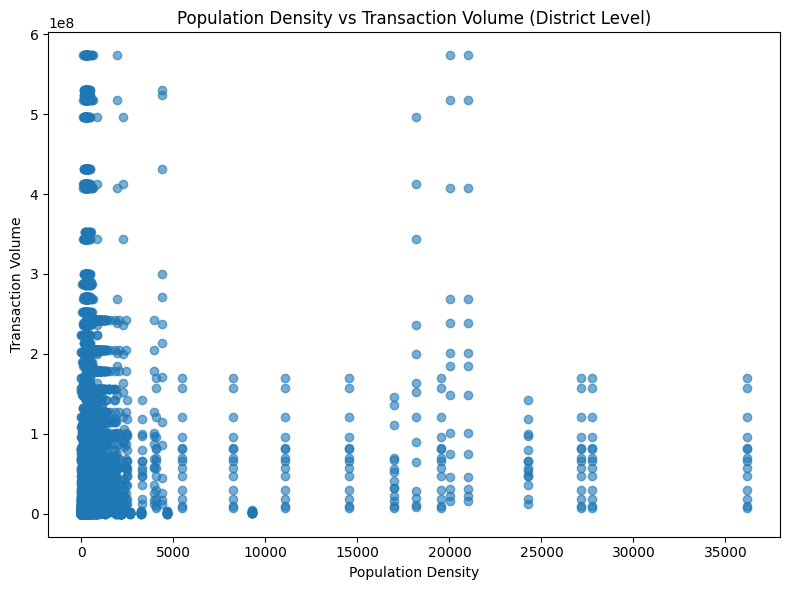

In [129]:
#3. Create a scatter plot to visualize the correlation between population density and transaction volume.

plt.figure(figsize=(8,6))
plt.scatter(merged['Density'], merged['Transactions'], alpha=0.6)
plt.xlabel('Population Density')
plt.ylabel('Transaction Volume')
plt.title('Population Density vs Transaction Volume (District Level)')
plt.tight_layout()
plt.show()

# 4.3: Average transaction amount per user

In [16]:
#1. Merge relevant datasets to calculate the average transaction amount per user for each state. Display the results in a tabular format.

state_summary =  State_Txn_and_Users.groupby('State').agg({'Amount (INR)': 'sum', 'Registered Users': 'sum'}).reset_index()
state_summary['Avg_Amount_per_User'] = state_summary['Amount (INR)'] / state_summary['Registered Users']
state_summary[['State', 'Avg_Amount_per_User']]


,State,Avg_Amount_per_User
0,Andaman & Nicobar Islands,8917.369075
1,Andhra Pradesh,20175.233763
2,Arunachal Pradesh,11949.126662
3,Assam,10476.576498
4,Bihar,14221.991933
5,Chandigarh,14129.308175
6,Chhattisgarh,11098.884128
7,Dadra & Nagar Haveli and Daman & Diu,6907.815954
8,Delhi,17299.587909
9,Goa,9309.966756


In [20]:
#2. Identify the top 5 states with the highest average transaction amount per user and the top 5 states with
#the lowest average transaction amount per user.

top5_state = state_summary.sort_values('Avg_Amount_per_User', ascending=False).head(5)
top5_state[['State', 'Avg_Amount_per_User']]

,State,Avg_Amount_per_User
31,Telangana,30653.509622
15,Karnataka,21474.282206
1,Andhra Pradesh,20175.233763
28,Rajasthan,17530.768707
8,Delhi,17299.587909


In [21]:
bottom5 = state_summary.sort_values('Avg_Amount_per_User').head(5)
bottom5[['State', 'Avg_Amount_per_User']]

,State,Avg_Amount_per_User
18,Lakshadweep,5614.898889
32,Tripura,5727.184275
7,Dadra & Nagar Haveli and Daman & Diu,6907.815954
16,Kerala,7274.846690
12,Himachal Pradesh,7317.601442


#  4.4: Device brand usage ratio

3. Create a bar chart depicting the device brand usage ratio for each state.

In [68]:
# 1. Merge the State_DeviceData dataset with the State_Txn and Users dataset.

merged_state = pd.merge(State_Txn_and_Users, State_DeviceData, on = ['State', 'Year', 'Quarter'])
merged_state.head(5)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users_x,App Opens,Brand,Registered Users_y,Percentage
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,Xiaomi,1665,0.247033
1,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,Samsung,1445,0.214392
2,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,Vivo,982,0.145697
3,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,Oppo,501,0.074332
4,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0,OnePlus,332,0.049258


In [69]:
#2. Calculate the ratio of users using each device brand to the total number of registered users in each state. Display the results in a tabular format.

merged_state['User_Ratio (%)'] = (merged_state['Registered Users_x']/
                merged_state['Registered Users_y']) * 100
result =  merged_state[['State','Brand','Registered Users_x', 'Registered Users_y','User_Ratio (%)']]
result

,State,Brand,Registered Users_x,Registered Users_y,User_Ratio (%)
0,Andaman & Nicobar Islands,Xiaomi,6740,1665,404.804805
1,Andaman & Nicobar Islands,Samsung,6740,1445,466.435986
2,Andaman & Nicobar Islands,Vivo,6740,982,686.354379
3,Andaman & Nicobar Islands,Oppo,6740,501,1345.309381
4,Andaman & Nicobar Islands,OnePlus,6740,332,2030.120482
...,...,...,...,...,...
5539,West Bengal,Lenovo,17979979,350841,5124.822640
5540,West Bengal,Asus,17979979,297579,6042.085967
5541,West Bengal,Huawei,17979979,272965,6586.917370
5542,West Bengal,Apple,17979979,201393,8927.807322


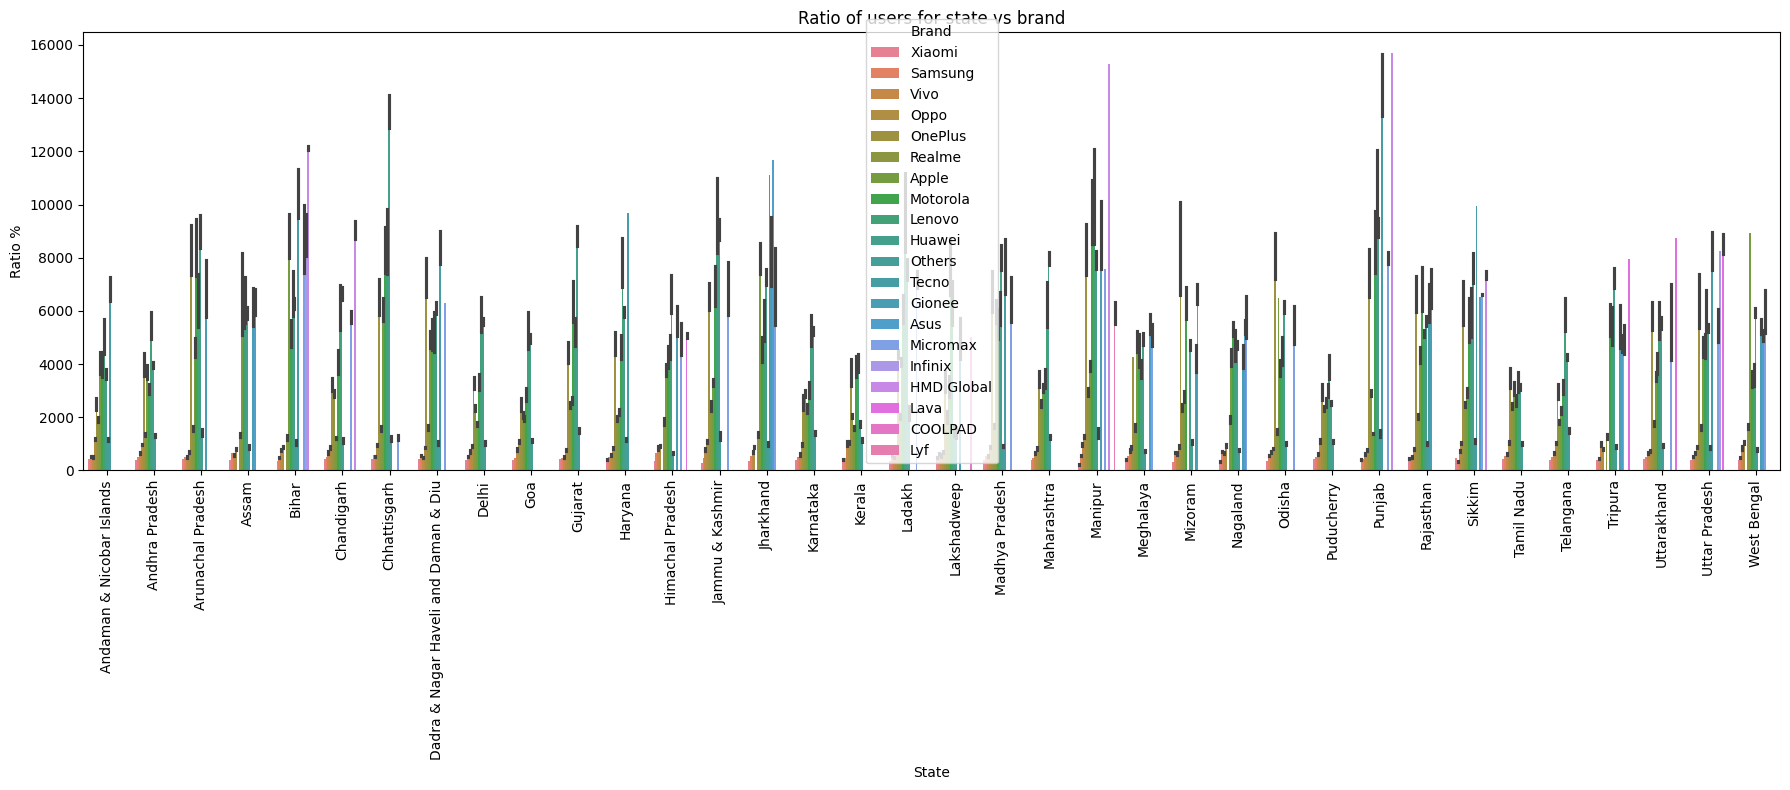

In [70]:
plt.figure(figsize =(18,8))
sns.barplot(
    data=merged_state,
    x='State',
    y='User_Ratio (%)',
    hue='Brand')

plt.xticks(rotation = 90)
plt.xlabel('State')
plt.ylabel('Ratio %')
plt.title('Ratio of users for state vs brand')
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [71]:
State_Txn_and_Users.head(5)

,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,1.463176e+07,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,2.833854e+07,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,5.555747e+07,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,9.054834e+07,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,1.022997e+08,3355.630147,18596,0


# Task 5: Data Visualization
5.1: Plot the total transactions and amount over time for a selected state

In [152]:
#1. Create a line plot showing the total number of transactions and the total transaction amount over time (years and quarters) for a selected state.

state = 'Punjab'
state_data = State_Txn_and_Users[State_Txn_and_Users['State'] == state]

amt_trans_over_time = state_data.groupby(
    ['Year', 'Quarter']
).agg({
    'Transactions': 'sum',
    'Amount (INR)': 'sum'
}).reset_index()

state_data['Time'] = state_data['Year'].astype(str) + ' Q' + state_data['Quarter'].astype(str)





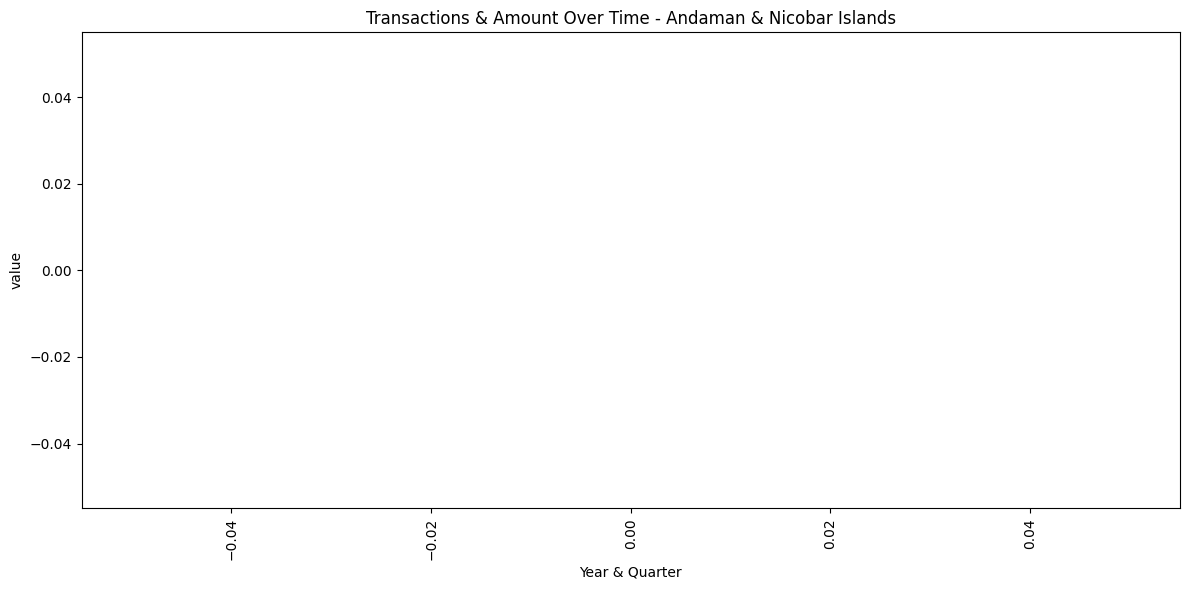

In [153]:
amt_trans_over_time['Year Quarter'] = state_data['Year'].astype(str) + " Q" + state_data['Quarter'].astype(str)

plt.figure(figsize = (12,6))
plt.plot(amt_trans_over_time['Year Quarter'],
        amt_trans_over_time['Transactions'],
        marker = 'o',
        label = 'Total Transaction')

plt.plot(amt_trans_over_time['Year Quarter'],
        amt_trans_over_time['Amount (INR)'],
        marker = 'o',
        label = 'Total Transactions Amount')

plt.xticks(rotation = 90)
plt.xlabel('Year & Quarter')
plt.ylabel('value')
plt.title(f'Transactions & Amount Over Time - {selected_state}')
plt.tight_layout()
plt.show()

# 5.2: Create a pie chart showing the distribution of transaction types for a specific quarter

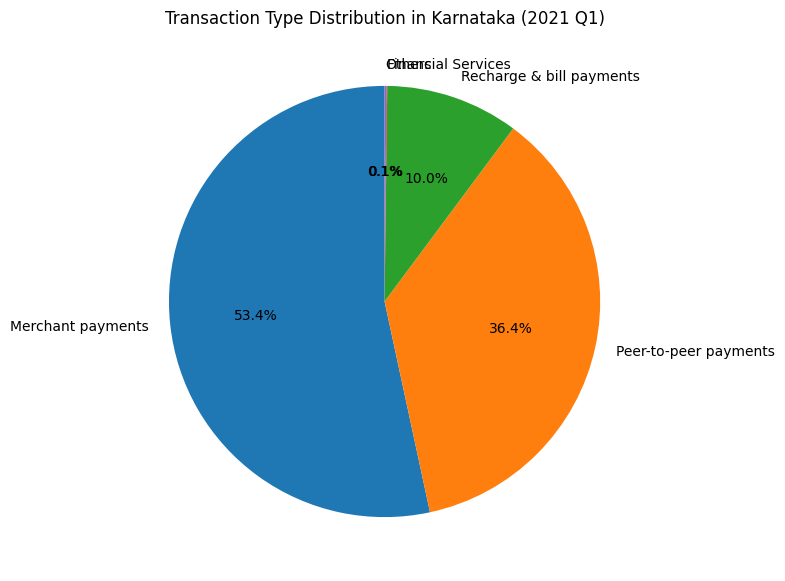

In [125]:
#1. Create a pie chart showing the distribution of different transaction types for a selected state and quarter.

state = 'Karnataka'
year = 2021
quarter = 1

filtered = State_TxnSplit[(State_TxnSplit['State'] == state) &
(State_TxnSplit['Year'] == year) &
(State_TxnSplit['Quarter'] == quarter)]

plt.figure(figsize = (7,7))
plt.pie(
    filtered['Transactions'],
    labels = filtered['Transaction Type'],
    autopct = '%1.1f%%',
    startangle = 90
)
plt.title(f'Transaction Type Distribution in {state} ({year} Q{quarter})')
plt.show()

# 5.3: Visualize the population density of districts in a selected state

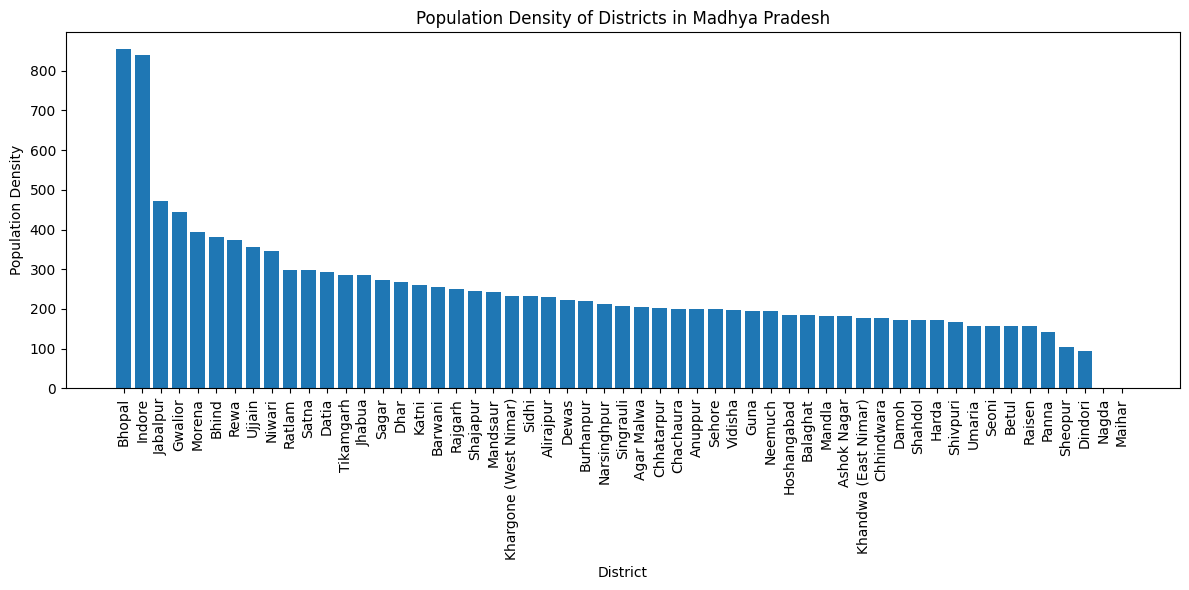

In [142]:
    # 1. Create a bar plot showing the population density of districts in a selected state.
#District_Demographics.head(5)
state = 'Madhya Pradesh'
state_districts = District_Demographics[District_Demographics['State'] == state]

state_districts = state_districts.sort_values(by = 'Density', ascending = False)

plt.figure(figsize=(12,6))
plt.bar(state_districts['District'],
       state_districts['Density'])
plt.xticks(rotation=90)
plt.xlabel('District')
plt.ylabel('Population Density')
plt.title(f'Population Density of Districts in {state}')
plt.tight_layout()
plt.show()